In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../results/plots", exist_ok=True)


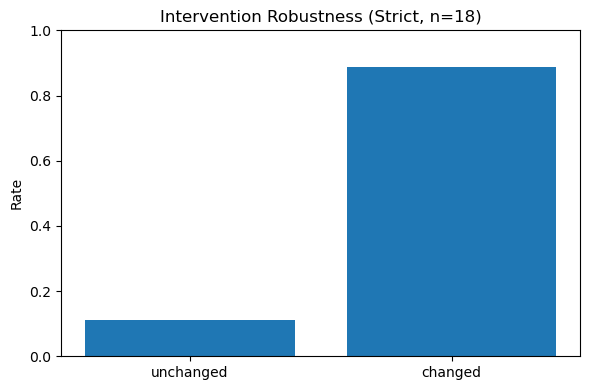

In [2]:
intv_raw = pd.read_csv("../results/intervention.csv")

required_cols = {"new_source", "original_source"}
missing = required_cols - set(intv_raw.columns)
if missing:
    raise ValueError(f"Strict mode requires columns: {sorted(required_cols)}; missing: {sorted(missing)}")

intv = intv_raw[(intv_raw["new_source"] == "model") & (intv_raw["original_source"] != "unknown")].copy()
intv.to_csv("../results/intervention_strict.csv", index=False)

if intv.empty:
    raise ValueError("Strict subset is empty. Collect more rows with new_source=model first.")

ratio = float(intv["unchanged"].mean())

plt.figure(figsize=(6, 4))
plt.bar(["unchanged", "changed"], [ratio, 1 - ratio])
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title(f"Intervention Robustness (Strict, n={len(intv)})")
plt.tight_layout()
plt.savefig("../results/plots/intervention.png", dpi=200)
plt.show()


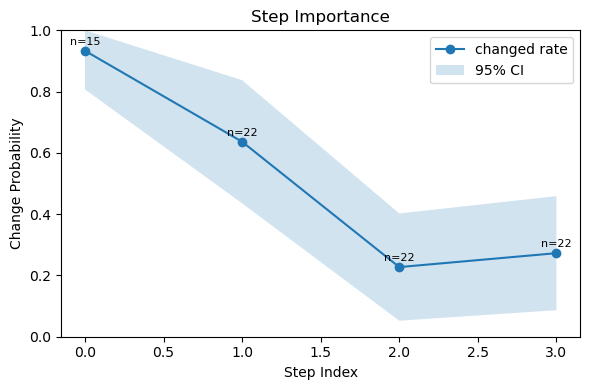

In [3]:
imp = pd.read_csv("../results/importance.csv")

g = imp.groupby("step_index")["changed"].agg(["mean", "count"]).reset_index()
g["se"] = np.sqrt((g["mean"] * (1 - g["mean"]) / g["count"]).clip(lower=0))
g["lo"] = (g["mean"] - 1.96 * g["se"]).clip(0, 1)
g["hi"] = (g["mean"] + 1.96 * g["se"]).clip(0, 1)

plt.figure(figsize=(6, 4))
plt.plot(g["step_index"], g["mean"], marker="o", label="changed rate")
plt.fill_between(g["step_index"], g["lo"], g["hi"], alpha=0.2, label="95% CI")
for _, r in g.iterrows():
    plt.text(r["step_index"], r["mean"] + 0.02, f"n={int(r['count'])}", ha="center", fontsize=8)
plt.ylim(0, 1)
plt.xlabel("Step Index")
plt.ylabel("Change Probability")
plt.title("Step Importance")
plt.legend()
plt.tight_layout()
plt.savefig("../results/plots/importance.png", dpi=200)
plt.show()


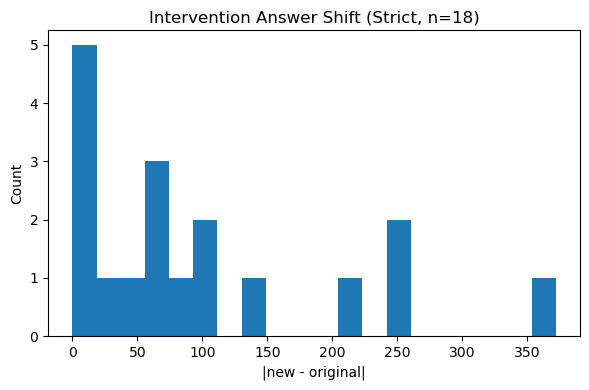

In [4]:
d = intv.copy()
d["original_answer"] = pd.to_numeric(d["original_answer"], errors="coerce")
d["new_answer"] = pd.to_numeric(d["new_answer"], errors="coerce")
d = d.dropna(subset=["original_answer", "new_answer"])
d["abs_delta"] = (d["new_answer"] - d["original_answer"]).abs()

if d.empty:
    raise ValueError("No numeric rows in strict subset for delta histogram.")

plt.figure(figsize=(6, 4))
plt.hist(d["abs_delta"], bins=20)
plt.xlabel("|new - original|")
plt.ylabel("Count")
plt.title(f"Intervention Answer Shift (Strict, n={len(d)})")
plt.tight_layout()
plt.savefig("../results/plots/intervention_delta_hist.png", dpi=200)
plt.show()
